<a href="https://colab.research.google.com/github/jivaniaadit/factor_xa_cheminformatics/blob/main/notebooks/Week2Day2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install rdkit -q

In [ ]:
from rdkit import Chem, DataStructs
from rdkit.Chem import Draw, Descriptors, rdMolDescriptors, rdFingerprintGenerator, AllChem, DataStructs
import pandas as pd
import numpy as np
from rdkit.Chem import MolStandardize
from rdkit.Chem.MolStandardize import rdMolStandardize
from rdkit.ML.Cluster import Butina
from rdkit import DataStructs
!pip install umap-learn

import umap
import numpy as np
from rdkit import Chem, DataStructs
from rdkit.Chem import rdFingerprintGenerator

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
df_clean = pd.read_csv('/content/drive/MyDrive/drugproj/factor_xa_clustered.csv')
print(df_clean.shape)
print(df_clean['cluster_id'].nunique(), "clusters")
df_clean.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(3477, 12)
656 clusters


,canonical_smiles,molecule_chembl_id,relation,standard_relation,standard_units,standard_value,units,value,canonical_smiles_std,is_pains,pKi,cluster_id
0,CC(=N)N1CCC(Oc2ccc3nc(CCC(=O)O)n(Cc4ccc5ccc(C(...,CHEMBL369583,=,=,nM,1.30,nM,1.300,CC(=N)N1CCC(Oc2ccc3nc(CCC(=O)O)n(Cc4ccc5ccc(C(...,False,8.886057,15
1,CC(=N)N1CCC(Oc2ccc3c(c2)nc(C(C)C)n3Cc2ccc3ccc(...,CHEMBL176744,=,=,nM,2.00,nM,2.000,CC(=N)N1CCC(Oc2ccc3c(c2)nc(C(C)C)n3Cc2ccc3ccc(...,False,8.698970,15
2,CCC(C)c1nc2cc(OC3CCN(C(C)=N)CC3)ccc2n1Cc1ccc2c...,CHEMBL367476,=,=,nM,3.30,nM,3.300,CCC(C)c1nc2cc(OC3CCN(C(C)=N)CC3)ccc2n1Cc1ccc2c...,False,8.481486,15
3,CC1CCN(C(=O)[C@H](Cc2cccc(C(=N)N)c2)NS(=O)(=O)...,CHEMBL145741,=,=,nM,1999.86,NaN,5.699,CC1CCN(C(=O)C(Cc2cccc(C(=N)N)c2)NS(=O)(=O)c2c(...,False,5.699000,26
4,COC(=O)[C@H]1Cc2ccccc2CN1C(=O)[C@H](Cc1cccc(C(...,CHEMBL145795,=,=,nM,26977.39,NaN,4.569,COC(=O)C1Cc2ccccc2CN1C(=O)C(Cc1cccc(C(=N)N)c1)...,False,4.569000,19


In [ ]:
#Regenerate fingerprints.
#Fingerprints don't survive CSV. Recompute from the standardized SMILES, same generator settings as yesterday so everything stays consistent:
mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
mols = [Chem.MolFromSmiles(s) for s in df_clean['canonical_smiles_std']]
fps = [mfpgen.GetFingerprint(m) for m in mols]
print(f"{len(fps)} fingerprints")

3477 fingerprints


In [ ]:
#Convert fingerprints to a numpy matrix.
#UMAP wants a 2D array. RDKit has a built in converter:
fp_array = np.zeros((len(fps), 2048), dtype=np.int8)
for i, fp in enumerate(fps):
    DataStructs.ConvertToNumpyArray(fp, fp_array[i])

print(fp_array.shape, fp_array.dtype)

(3477, 2048) int8


In [ ]:
#UMAP
reducer = umap.UMAP(
    metric='jaccard',
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)
embedding = reducer.fit_transform(fp_array)
print(embedding.shape)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1887: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(3477, 2)


In [ ]:
np.save('/content/drive/MyDrive/drugproj/umap_embedding.npy', embedding)

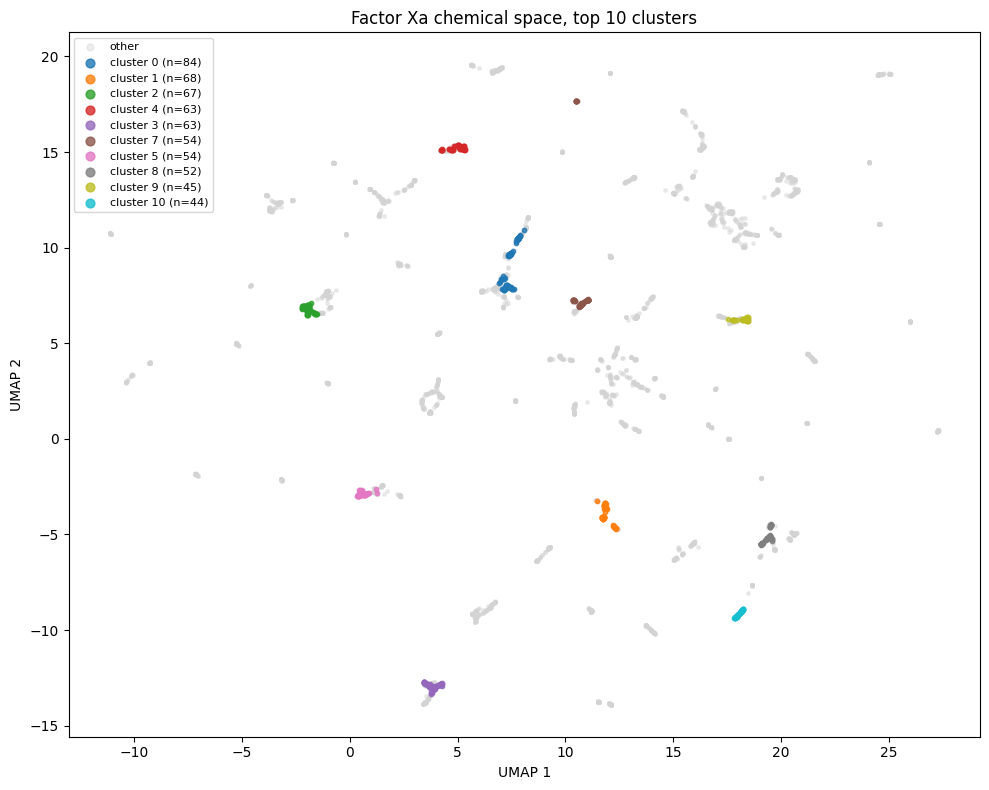

In [ ]:
#Plot colored by cluster (top 10 only).
import matplotlib.pyplot as plt

top_n = 10
top_clusters = df_clean['cluster_id'].value_counts().head(top_n).index.tolist()

fig, ax = plt.subplots(figsize=(10, 8))

# gray background: everything not in top 10
mask_other = ~df_clean['cluster_id'].isin(top_clusters)
ax.scatter(embedding[mask_other, 0], embedding[mask_other, 1],
           c='lightgray', s=6, alpha=0.4, label='other')

# colored: top 10 clusters
cmap = plt.cm.tab10
for i, cid in enumerate(top_clusters):
    mask = df_clean['cluster_id'] == cid
    ax.scatter(embedding[mask, 0], embedding[mask, 1],
               c=[cmap(i)], s=10, alpha=0.8,
               label=f'cluster {cid} (n={mask.sum()})')

ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_title('Factor Xa chemical space, top 10 clusters')
ax.legend(loc='best', fontsize=8, markerscale=2)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/drugproj/umap_clusters.png', dpi=150)
plt.show()

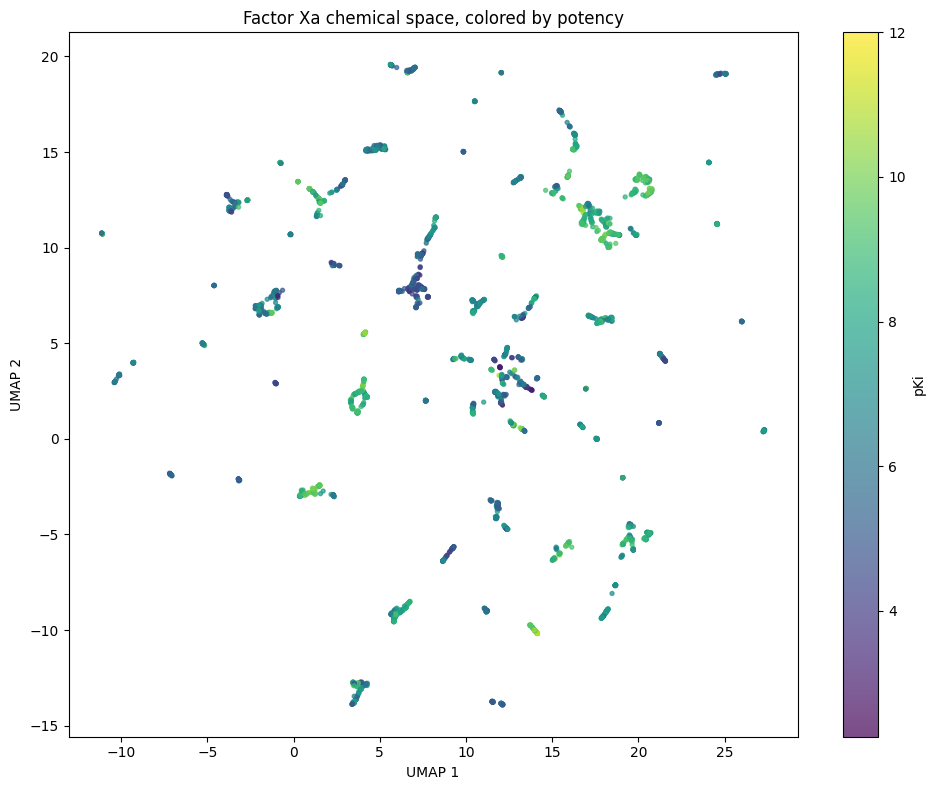

In [ ]:
#pKi colored
fig, ax = plt.subplots(figsize=(10, 8))
sc = ax.scatter(embedding[:, 0], embedding[:, 1],
                c=df_clean['pKi'], cmap='viridis',
                s=8, alpha=0.7)
plt.colorbar(sc, label='pKi')
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_title('Factor Xa chemical space, colored by potency')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/drugproj/umap_pki.png', dpi=150)
plt.show()

In [ ]:
#Identify and look at the brightest spot.
top_idx = df_clean['pKi'].idxmax()
print(f"Most active: pKi {df_clean.loc[top_idx, 'pKi']:.2f}")
print(f"SMILES: {df_clean.loc[top_idx, 'canonical_smiles_std']}")
print(f"UMAP coords: ({embedding[top_idx, 0]:.2f}, {embedding[top_idx, 1]:.2f})")
print(f"Cluster: {df_clean.loc[top_idx, 'cluster_id']}")

# how many compounds within radius 1.0 in UMAP space?
from scipy.spatial.distance import cdist
dists_2d = cdist(embedding[top_idx:top_idx+1], embedding)[0]
neighbors_in_radius = (dists_2d < 1.0).sum()
print(f"Compounds within UMAP radius 1.0: {neighbors_in_radius}")
print(f"Mean pKi of those neighbors: {df_clean.loc[dists_2d < 1.0, 'pKi'].mean():.2f}")

#If the neighborhood mean pKi is high (say 8+), that's an activity hot spot. If it's average (around 6 to 7), the top compound is an outlier in its local space, which is an activity cliff signal.

Most active: pKi 12.00
SMILES: N=C(N)c1cccc(-n2nc(C(F)(F)F)cc2C(=O)Nc2ncc(-c3ccccc3S(N)(=O)=O)cn2)c1
UMAP coords: (16.79, 12.01)
Cluster: 224
Compounds within UMAP radius 1.0: 129
Mean pKi of those neighbors: 8.38


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/pairwise.py:2466: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


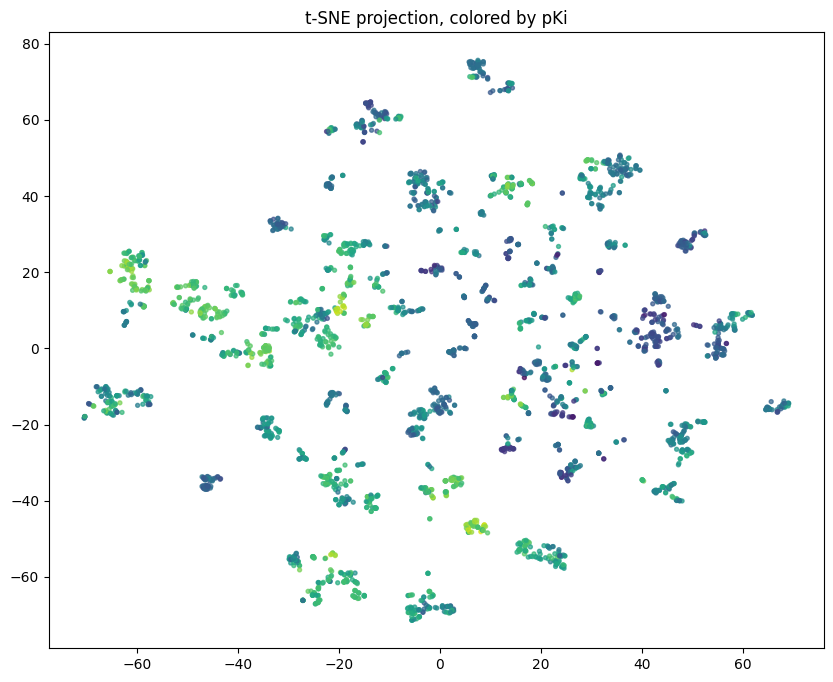

In [ ]:
#t-SNE for comparison.
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, metric='jaccard', random_state=42, init='random')
tsne_embedding = tsne.fit_transform(fp_array)

fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(tsne_embedding[:, 0], tsne_embedding[:, 1],
           c=df_clean['pKi'], cmap='viridis', s=8, alpha=0.7)
ax.set_title('t-SNE projection, colored by pKi')
plt.show()

In [ ]:
df_clean['umap_1'] = embedding[:, 0]
df_clean['umap_2'] = embedding[:, 1]
df_clean.to_csv('/content/drive/MyDrive/drugproj/factor_xa_clustered.csv', index=False)